# Reporting and Insight Generation

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('libraries loaded!')

libraries loaded!


In [32]:
df = pd.read_csv('SuperMarket_Analysis.csv')
print('dataset loaded')
print('shape:', df.shape)
df.head()

dataset loaded
shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [33]:
print('column names:')
print(df.columns.tolist())
print()
print('missing values:')
print(df.isnull().sum())

column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

missing values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [34]:
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])
print('data cleaned!')
print('shape after cleaning:', df.shape)

data cleaned!
shape after cleaning: (1000, 17)


In [35]:
print('Key Business Metrics:')
print()
print('Total Revenue:', round(df['Sales'].sum(), 2))
print('Average Transaction Value:', round(df['Sales'].mean(), 2))
print('Total Number of Orders:', len(df))
print('Average Rating:', round(df['Rating'].mean(), 2))

Key Business Metrics:

Total Revenue: 322966.75
Average Transaction Value: 322.97
Total Number of Orders: 1000
Average Rating: 6.97


In [36]:
branch_sales = df.groupby('Branch')['Sales'].sum().sort_values(ascending=False)
print('branch wise revenue:')
print(branch_sales)

branch wise revenue:
Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


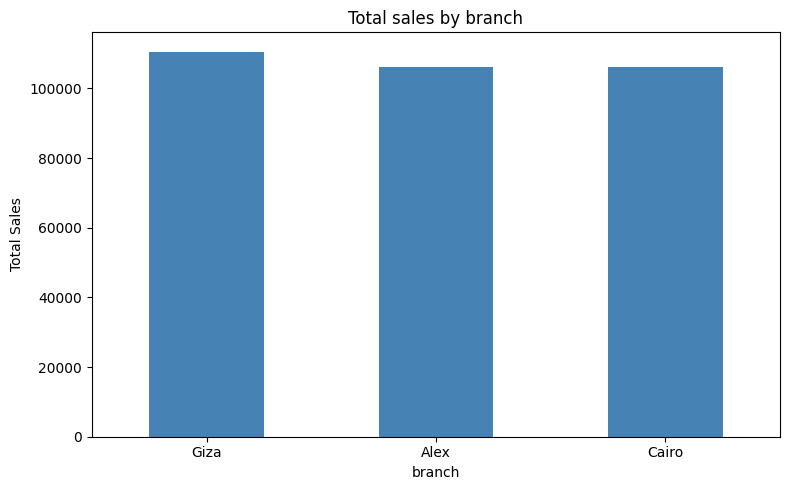

In [37]:
plt.figure(figsize=(8, 5))
branch_sales.plot(kind='bar', color='steelblue')
plt.title('Total sales by branch')
plt.xlabel('branch')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
product_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
print('product line wise revenue:')
print(product_sales)

product line wise revenue:
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


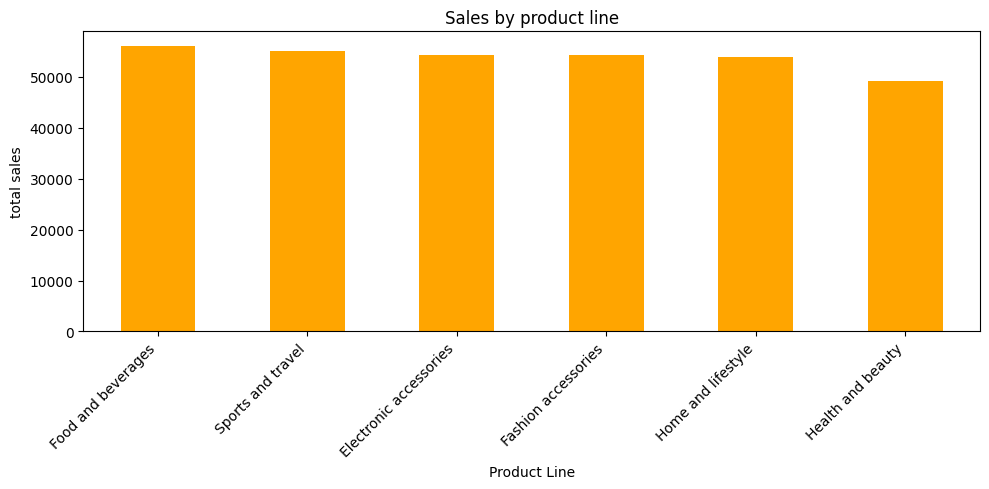

In [39]:
plt.figure(figsize=(10, 5))
product_sales.plot(kind='bar', color='orange')
plt.title('Sales by product line')
plt.xlabel('Product Line')
plt.ylabel('total sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
gender_sales = df.groupby('Gender')['Sales'].sum()
print('gender wise sales:')
print(gender_sales)

gender wise sales:
Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


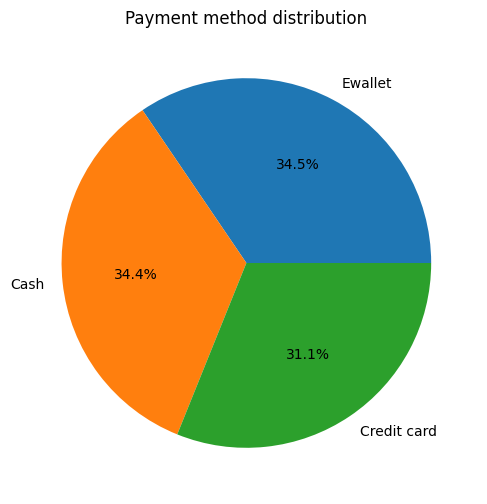

In [41]:
plt.figure(figsize=(6, 6))
df['Payment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment method distribution')
plt.ylabel('')
plt.show()

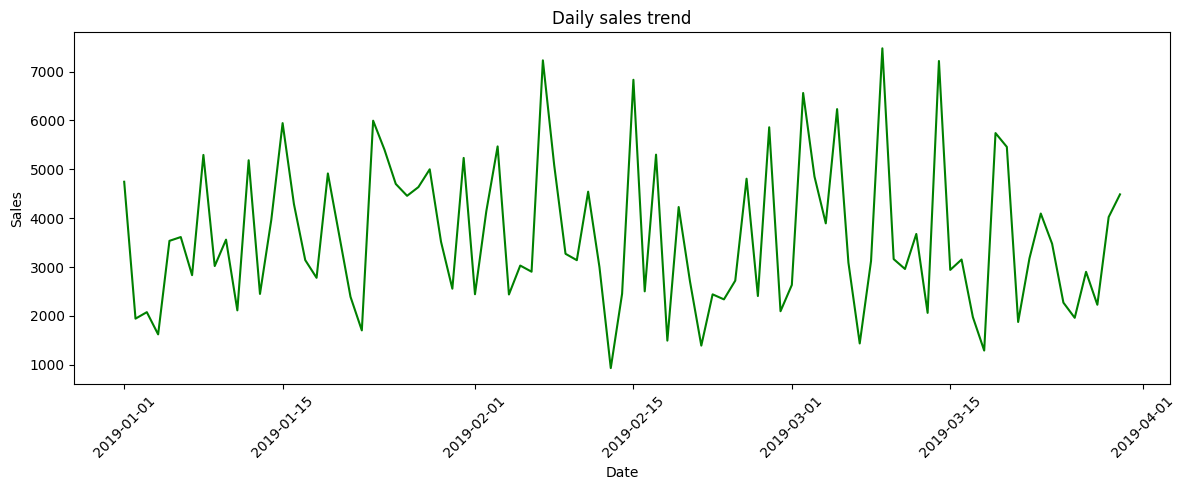

In [42]:
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color='green')
plt.title('Daily sales trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

average sales by customer type:
Customer type
Member    335.742945
Normal    306.372379
Name: Sales, dtype: float64


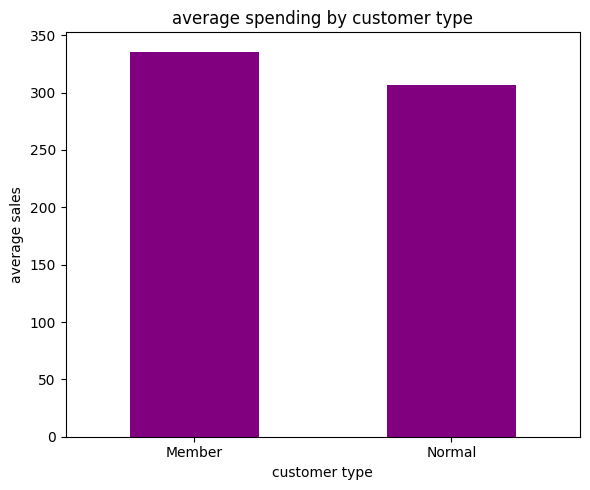

In [43]:
customer_sales = df.groupby('Customer type')['Sales'].mean()
print('average sales by customer type:')
print(customer_sales)

plt.figure(figsize=(6, 5))
customer_sales.plot(kind='bar', color='purple')
plt.title('average spending by customer type')
plt.xlabel('customer type')
plt.ylabel('average sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
print('='*50)
print('FINAL INSIGHT REPORT')
print('='*50)
print()
print('1. Total revenue generated:', round(df['Sales'].sum(), 2))
print('2. Best performing branch:', branch_sales.idxmax())
print('3. Best selling product line:', product_sales.idxmax())
print('4. Most preferred payment method:', df['Payment'].mode()[0])
print('5. Member customers spend more on average than normal customers')
print('6. Average customer rating is', round(df['Rating'].mean(), 2), 'out of 10')
print('7. Food and beverages along with electronic accessories are top categories')
print('8. Sales are fairly consistent across all three branches')
print()
print('Recommendation: Focus marketing efforts on the best performing product line')
print('and encourage more customers to join membership for higher spending')
print('='*50)

FINAL INSIGHT REPORT

1. Total revenue generated: 322966.75
2. Best performing branch: Giza
3. Best selling product line: Food and beverages
4. Most preferred payment method: Ewallet
5. Member customers spend more on average than normal customers
6. Average customer rating is 6.97 out of 10
7. Food and beverages along with electronic accessories are top categories
8. Sales are fairly consistent across all three branches

Recommendation: Focus marketing efforts on the best performing product line
and encourage more customers to join membership for higher spending


## Summary

In this project i generated business insights and reports from a supermarket sales dataset using python.

- loaded and cleaned the supermarket sales dataset
- calculated total revenue, average transaction value and total orders
- analyzed branch wise and product line wise sales performance
- visualized payment method distribution and daily sales trend
- compared spending patterns between member and normal customers
- generated a final insight report with key findings and recommendations
- this project helped me understand how to turn raw data into actionable business insights